# 00 · Validación y cruce: ventas Bepensa × Customer Potential (CP) — ZM Mérida

**Papel en la metodología Golden Stores (notebook 05):** valida la **variable 1, ventas de la tienda**, y las señales del CP
(potencial futuro, usado para clasificar). La variable 2, demanda potencial a 300 m, la construye el notebook 04.

**Objetivo:** dejar una tabla limpia, **una fila por punto de venta (PDV) con coordenadas**, con sus ventas y su
potencial, y decidir con **evidencia estadística** (prueba, tamaño de efecto e intervalo de confianza) qué señales
sirven y cuáles no. Esa tabla alimenta el notebook 04 (perfil NSE e indicadores en hexágonos a ≤ 300 m de cada PDV).

**Alcance:** el CP y las ventas cubren toda la península. La llave se infiere con toda la base (más evidencia) y
después **todo el análisis se hace solo con los PDV de la ZM Mérida** (cruce espacial con los polígonos municipales
del Marco Geoestadístico 2025).

**Fuentes (del cliente, en `data/raw/bepensa/`, no se suben a git):**

| Archivo | Qué trae | Grano |
|---|---|---|
| `ventas/part-*.csv` | cajas vendidas por PDV y categoría, meses activos, primera y última venta | PDV × categoría (solo `sueros`) |
| `cp/conservative_scenario.csv` | coordenadas, subcanal, tamaño, cluster y potencial (escenario conservador) | PDV |

**Convenciones (método retail-math-eda):**
* **Grano:** ventas = `pos_id` × `custom_category`; CP = `pos_id`. Se verifica que ambas llaves sean únicas.
* **Ventana:** oct-2024 → ago-2026 (23 meses). Las ventas vienen agregadas por PDV: no hay transacciones, precios
  ni canasta, así que market basket, RFM transaccional y elasticidad **no aplican**.
* **Unidad:** cajas (sin importes). Sin devoluciones (se verifica que no haya negativos).
* **Inferencia:** toda p se corrige por comparaciones múltiples con Benjamini-Hochberg (q). Con n ≈ 6,000 casi todo
  es "significativo", así que se decide por **tamaño de efecto** (ρ, ε², δ de Cliff, V de Cramér) y su IC95.

**Reproducir:** es el **primer** notebook: no depende de 01–03 (orden completo 00 → 01 → 02 → 03 → 04). Ábrelo desde
`notebooks/` o corre `python src/correr.py --pasos 00 merida`. Necesita los datos del cliente en `data/raw/bepensa/`
(el Marco Geoestadístico se descarga solo si falta) y los paquetes de `requirements.txt`.
Todo lo aleatorio usa la semilla fija `eda.SEMILLA`.

In [1]:
# --- parámetros y entorno (lo único que se cambiaría a mano) ---
import os
import sys
import platform
from pathlib import Path

os.environ.setdefault("CIUDAD", "merida")       # Bepensa se analiza para la ZM Mérida; cambiar antes de importar config
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(BASE / "src"))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import scipy
import sklearn
from scipy import stats
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from IPython.display import display

import config as C
import cadenas
import eda
from descargas import descargar, extraer

assert C.CIUDAD == C.CLIENTE_CIUDAD, f"Los datos de {C.CLIENTE} son de {C.CLIENTE_CIUDAD}; CIUDAD={C.CIUDAD}"
eda.estilo()
pd.set_option("display.width", 220, "display.max_columns", 40, "display.float_format", "{:,.3f}".format)
print(f"Repo: {BASE} | ciudad: {C.ZM_NOMBRE} | semilla: {eda.SEMILLA}")
print(f"Python {platform.python_version()} · pandas {pd.__version__} · numpy {np.__version__} · scipy {scipy.__version__} · "
      f"scikit-learn {sklearn.__version__} · geopandas {gpd.__version__}")

# --- requisitos: datos del cliente y polígonos municipales del Marco Geoestadístico ---
# Ventas y Customer Potential son los insumos críticos: sin ellos no hay Golden Stores (se piden al cliente, no se sustituyen)
assert C.CLIENTE_VENTAS, f"No hay archivos part-*.csv en {C.CLIENTE_RAW / 'ventas'}: pedir las ventas por PDV al cliente"
for f in [C.CLIENTE_CP, *C.CLIENTE_VENTAS]:
    assert Path(f).exists(), f"Falta el archivo del cliente: {f} (pedirlo al cliente; no se puede avanzar sin él)"
# registro de la versión exacta de los datos del cliente (para reproducir y detectar si cambian): tamaño, filas, fecha y SHA-256
import hashlib
from datetime import datetime
FUENTES_CLIENTE = pd.DataFrame([{
    "insumo": "Customer Potential" if Path(f) == Path(C.CLIENTE_CP) else "Ventas por PDV", "archivo": Path(f).name,
    "ruta": str(Path(f).relative_to(BASE)), "bytes": Path(f).stat().st_size,
    "filas": sum(1 for _ in open(f, encoding="utf-8", errors="ignore")) - 1,
    "modificado": datetime.fromtimestamp(Path(f).stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
    "sha256": hashlib.sha256(Path(f).read_bytes()).hexdigest()} for f in [*C.CLIENTE_VENTAS, C.CLIENTE_CP]])
FUENTES_CLIENTE.to_csv(C.PROC / f"fuentes_cliente_{C.CLIENTE}_00.csv", index=False)
display(FUENTES_CLIENTE)
descargar(C.URLS["mg"], C.ARCHIVOS["mg"])       # no vuelve a bajar si el zip ya existe y abre bien
D_MG = extraer(C.ARCHIVOS["mg"], C.RAW / f"mg{C.MG_VERSION}_{C.ENT}")

Repo: C:\Users\KIN\Desktop\Kin\mx-retail-geodemographics | ciudad: ZM Mérida | semilla: 2026
Python 3.14.6 · pandas 3.0.5 · numpy 2.5.1 · scipy 1.18.1 · scikit-learn 1.9.0 · geopandas 1.1.4


,insumo,archivo,ruta,bytes,filas,modificado,sha256
0,Ventas por PDV,part-00000-517750b7-4e1e-491b-a3d9-da777a4085f...,data\raw\bepensa\ventas\part-00000-517750b7-4e...,2391803,41341,2026-09-25 18:26,d80b28eecae039d3b0adb1ceb9d25dcde3f3e5814ccbd2...
1,Customer Potential,conservative_scenario.csv,data\raw\bepensa\cp\conservative_scenario.csv,7583333,36823,2026-09-25 18:27,7c57f4ebbd9729d04a52a44ddfb99565f215b3590529a3...


[ok] ya existe mg2025eic_31_yucatan.zip


## 1. Carga e integridad

In [2]:
ventas = pd.concat([pd.read_csv(f) for f in C.CLIENTE_VENTAS], ignore_index=True)
cp = pd.read_csv(C.CLIENTE_CP)
cp[["cadena", "canal"]] = cadenas.clasificar(cp.pos_name)        # mismo criterio que las tiendas DENUE (src/cadenas.py)
print("Archivos:", [f.name for f in C.CLIENTE_VENTAS], "|", C.CLIENTE_CP.name)
print(f"Ventas: {ventas.shape} | CP: {cp.shape}")
print("Llave ventas (pos_id, custom_category) única:", not ventas.duplicated(["pos_id", "custom_category"]).any(),
      "| categorías:", ventas.custom_category.value_counts().to_dict())
print("Llave CP (pos_id) única:", cp.pos_id.is_unique)
print("Negativos en ventas:", int((ventas.select_dtypes("number") < 0).sum().sum()))
print("avg_monthly_boxes = total_boxes_sold / n_active_months:",
      bool(np.allclose(ventas.avg_monthly_boxes, (ventas.total_boxes_sold / ventas.n_active_months).round(2), atol=0.011)))
nulos = cp.isna().mean().mul(100).round(1)
display(nulos[nulos > 0].to_frame("% nulos CP"))
print("Columnas de potencial nulas en bloque (mismo patrón en las 10):",
      bool(cp.filter(like="Potential").drop(columns=cp.filter(like="PotentialRange").columns).isna().nunique(axis=1).eq(1).all()))

Archivos: ['part-00000-517750b7-4e1e-491b-a3d9-da777a4085fc-c000.csv'] | conservative_scenario.csv
Ventas: (41341, 7) | CP: (36823, 24)
Llave ventas (pos_id, custom_category) única: True | categorías: {'sueros': 41341}
Llave CP (pos_id) única: True
Negativos en ventas: 0
avg_monthly_boxes = total_boxes_sold / n_active_months: True


,% nulos CP
cluster,1.000
size_class,18.100
PotentialQuantitative_TotalPortafolio,18.100
PotentialQualitative_TotalPortafolio,18.100
PotentialEstimatedToCover_TotalPortafolio,18.100
PotentialQuantitativeFinal_TotalPortafolio,18.100
Comparative_Client_ID_TotalPortafolio,18.100
PotentialQuantitative_CustomCat_sueros,18.100
PotentialQualitative_CustomCat_sueros,18.100
PotentialEstimatedToCover_CustomCat_sueros,18.100


Columnas de potencial nulas en bloque (mismo patrón en las 10): True


## 2. Llave entre ventas y CP

Los `pos_id` no coinciden directamente (ventas: 10 dígitos; CP: 1–480,475). Hipótesis H1:
**`pos_id` de ventas = prefijo de 4 dígitos (centro de distribución) + `pos_id` del CP a 6 dígitos**.

* **Prueba (a), empate vs azar.** Bajo H0 (sufijo sin relación con el CP) un sufijo de 6 dígitos cae en el CP con
  probabilidad p₀ = (#pos_id del CP) / 10⁶. Prueba binomial unilateral del número de empates.
* **Prueba (b), coherencia geográfica.** Si el prefijo es un centro de distribución, sus PDV se concentran en pocas
  ciudades. Estadístico: pureza = proporción ponderada de la ciudad dominante por prefijo. Se compara con su
  distribución bajo H0 permutando las ciudades (200 permutaciones, p = (#{T* ≥ T} + 1) / (B + 1)).

In [3]:
sid = ventas.pos_id.astype(str)
assert sid.str.len().eq(10).all()
ventas["prefijo"] = sid.str[:4]
ventas["pos_id_cp"] = sid.str[4:].astype(int)
ventas["en_cp"] = ventas.pos_id_cp.isin(cp.pos_id)

densidad = cp.pos_id.nunique() / 1_000_000
k, n = int(ventas.en_cp.sum()), len(ventas)
binom = stats.binomtest(k, n, densidad, alternative="greater")
ic = stats.binomtest(k, n).proportion_ci(0.95, method="wilson")      # IC bilateral (el de la prueba unilateral llega a 100%)
print(f"(a) Empate: {k:,}/{n:,} = {k / n:.1%} (IC95 Wilson {ic.low:.1%}–{ic.high:.1%}) vs p₀ = {densidad:.1%} | "
      f"binomial p = {binom.pvalue:.1e} | razón vs azar = {k / n / densidad:.0f}×")
print(f"    cajas cubiertas por el empate: {ventas.total_boxes_sold[ventas.en_cp].sum() / ventas.total_boxes_sold.sum():.1%}")

m = ventas[ventas.en_cp].merge(cp[["pos_id", "pos_city"]].rename(columns={"pos_id": "pos_id_cp"}), on="pos_id_cp")
def pureza(prefijo, ciudad):
    t = pd.crosstab(prefijo, ciudad)
    return float(t.max(axis=1).sum() / t.values.sum())
real = pureza(m.prefijo, m.pos_city)
rng = np.random.default_rng(eda.SEMILLA)
perm_dist = np.array([pureza(m.prefijo, rng.permutation(m.pos_city.values)) for _ in range(200)])
p_perm = (np.sum(perm_dist >= real) + 1) / (perm_dist.size + 1)
perm = perm_dist.mean()
print(f"(b) Pureza de ciudad por prefijo: real {real:.3f} vs permutada {perm:.3f} (máx. de 200: {perm_dist.max():.3f}) | "
      f"p de permutación = {p_perm:.4f} (el mínimo posible con 200)")
print(f"    V de Cramér prefijo × ciudad = {eda.cramer_v(pd.crosstab(m.prefijo, m.pos_city)):.2f}")

llave = (ventas.groupby("prefijo").agg(registros=("pos_id", "size"), empate=("en_cp", "mean"),
                                        cajas=("total_boxes_sold", "sum"))
         .join(m.groupby("prefijo").pos_city.agg(lambda x: x.value_counts().index[0]).rename("ciudad_principal"))
         .sort_values("registros", ascending=False))
display(llave.head(30))
print("Prefijos sin ningún empate:", llave.index[llave.empate == 0].tolist(),
      f"({llave.registros[llave.empate == 0].sum():,} registros)")
multi = ventas[ventas.en_cp].pos_id_cp.duplicated(keep=False)
print(f"PDV del CP atendidos por más de un prefijo: {ventas[ventas.en_cp & multi].pos_id_cp.nunique():,} (se suman al consolidar)")

# nulos del CP ⇔ PDV sin venta (MNAR): tabla 2×2 y V de Cramér
t_mnar = pd.crosstab(cp.PotentialQuantitative_TotalPortafolio.isna().rename("potencial nulo"),
                     cp.pos_id.isin(ventas.pos_id_cp[ventas.en_cp]).rename("con venta"))
display(t_mnar)
print(f"V de Cramér (potencial nulo × con venta) = {eda.cramer_v(t_mnar):.3f} → 1 = el CP solo tiene potencial para PDV que compran")

(a) Empate: 30,317/41,341 = 73.3% (IC95 Wilson 72.9%–73.8%) vs p₀ = 3.7% | binomial p = 0.0e+00 | razón vs azar = 20×
    cajas cubiertas por el empate: 50.5%


(b) Pureza de ciudad por prefijo: real 0.706 vs permutada 0.157 (máx. de 200: 0.158) | p de permutación = 0.0050 (el mínimo posible con 200)
    V de Cramér prefijo × ciudad = 0.64


,registros,empate,cajas,ciudad_principal
prefijo,,,,
1049,4070,0.669,"455,165.057",Benito Juárez
1031,3489,0.833,"303,907.790",MERIDA
1030,3247,0.849,"251,710.136",MERIDA
1034,2142,0.842,"152,367.610",TICUL
1011,2037,0.701,"216,916.475",Othón P. Blanco
1013,1824,0.833,"107,604.106",Campeche
1006,1805,0.793,"100,829.533",Valladolid
1087,1805,0.514,"317,146.163",Solidaridad
3049,1653,0.534,"806,339.343",Benito Juárez


Prefijos sin ningún empate: ['3043', '1097', '1001', '3027', '3097'] (745 registros)
PDV del CP atendidos por más de un prefijo: 157 (se suman al consolidar)


con venta,False,True
potencial nulo,,
False,0,30160
True,6663,0


V de Cramér (potencial nulo × con venta) = 1.000 → 1 = el CP solo tiene potencial para PDV que compran


**Supuesto a confirmar con Bepensa:** la llave se infirió de los datos. Las dos pruebas rechazan H0 con mucho margen,
pero una tabla oficial de equivalencias es mejor evidencia que cualquier prueba.

## 3. Limpieza de coordenadas del CP

Errores encontrados: lat/lon invertidas, punto decimal perdido (`21034767` → `21.034767`), signo de longitud perdido
y basura (lat = −lon). Reglas, en orden: (1) escala: si |valor| > 1000 se divide hasta quedar con dos dígitos enteros;
(2) si |lat| > 80 y |lon| < 30 se intercambian; (3) lat positiva, lon negativa; (4) caja de la península
(17.5–22.0 N, 86.5–92.5 O). La consistencia con el municipio se revisa en 3b con el polígono municipal.

In [4]:
def escala(v):
    v = v.astype(float).copy()
    g = v.abs() > 1000
    v[g] = v[g] / 10 ** (np.floor(np.log10(v[g].abs())) - 1)
    return v

lat, lon = escala(cp.pos_latitude), escala(cp.pos_longitude)
inv = (lat.abs() > 80) & (lon.abs() < 30)
lat, lon = lat.where(~inv, lon), lon.where(~inv, lat)
lat, lon = lat.abs(), -lon.abs()
valida = lat.between(17.5, 22.0) & lon.between(-92.5, -86.5)
original_ok = cp.pos_latitude.between(17.5, 22.0) & cp.pos_longitude.between(-92.5, -86.5)
cp["lat"], cp["lon"] = lat.where(valida), lon.where(valida)
cp["coord_estado"] = np.select([original_ok & valida, valida], ["original", "corregida"], "descartada (fuera de la península)")
cp_total_estado = cp.coord_estado.copy()        # base completa, antes de filtrar a la ZM
display(cp.coord_estado.value_counts().to_frame("PDV"))
display(cp.loc[cp.coord_estado != "original", ["pos_id", "pos_city", "pos_latitude", "pos_longitude", "lat", "lon", "coord_estado"]].head(20))

,PDV
coord_estado,
original,36771
corregida,45
descartada (fuera de la península),7


,pos_id,pos_city,pos_latitude,pos_longitude,lat,lon,coord_estado
431,2941,MERIDA,-89.651,20.927,20.927,-89.651,corregida
22710,419087,MERIDA,-89.674,20.915,20.915,-89.674,corregida
23140,421864,MERIDA,-89.675,20.890,20.890,-89.675,corregida
23376,423343,MERIDA,-89.636,20.916,20.916,-89.636,corregida
24964,433573,MERIDA,-89.667,20.919,20.919,-89.667,corregida
27502,448365,Benito Juárez,21.174,-83.827,NaN,NaN,descartada (fuera de la península)
28209,451492,MERIDA,89.658,-89.658,NaN,NaN,descartada (fuera de la península)
28661,453405,PROGRESO,21.280,89.649,21.280,-89.649,corregida
29742,458483,MERIDA,20.963,89.627,20.963,-89.627,corregida
30328,460896,MERIDA,24.026,-89.855,NaN,NaN,descartada (fuera de la península)


## 3b. Filtro a la ZM y sesgo de selección de las ventas que no se pueden ubicar

In [5]:
mun = gpd.read_file(next(D_MG.rglob(f"{C.ENT}mun.shp")))[["CVE_MUN", "NOMGEO", "geometry"]]
pts = gpd.GeoDataFrame(cp[["pos_id"]], geometry=gpd.points_from_xy(cp.lon, cp.lat), crs=4326).to_crs(mun.crs)
j = gpd.sjoin(pts[cp.lat.notna().values], mun, how="left", predicate="within")
cp["cve_mun"] = j.CVE_MUN.reindex(cp.index)
cp["municipio_mg"] = j.NOMGEO.reindex(cp.index)
cp["en_zm"] = cp.cve_mun.isin(C.ZM_MUNICIPIOS)
print(f"PDV del CP en {C.ZM_NOMBRE}: {cp.en_zm.sum():,} de {len(cp):,} (municipios: {C.ZM_MUNICIPIOS})")
display(pd.crosstab(cp.loc[cp.en_zm, "municipio_mg"], cp.loc[cp.en_zm, "pos_city"]))
dup = cp[cp.en_zm].duplicated(["lat", "lon"], keep=False)
print(f"PDV de la ZM con coordenadas idénticas a otro PDV: {dup.sum():,} (posibles dobles registros o geocodificación a nivel calle)")

zm_ids = set(cp.pos_id[cp.en_zm])
pref_zm = ventas[ventas.en_cp].assign(zm=lambda d: d.pos_id_cp.isin(zm_ids)).groupby("prefijo").zm.mean()
pref_zm = pref_zm[pref_zm >= 0.5].index.tolist()
vz = ventas[ventas.prefijo.isin(pref_zm)].copy()
vz["cajas_mes"] = vz.total_boxes_sold / vz.n_active_months
a, b = vz.loc[~vz.en_cp, "cajas_mes"], vz.loc[vz.en_cp, "cajas_mes"]
mw = stats.mannwhitneyu(a, b)
sesgo = pd.DataFrame({
    "grupo": ["sin empate (no ubicables)", "con empate (analizados)"],
    "registros": [len(a), len(b)],
    "% de las cajas": [vz.total_boxes_sold[~vz.en_cp].sum() / vz.total_boxes_sold.sum() * 100,
                       vz.total_boxes_sold[vz.en_cp].sum() / vz.total_boxes_sold.sum() * 100],
    "mediana cajas/mes activo": [eda.ic_bootstrap(a)[0], eda.ic_bootstrap(b)[0]],
    "IC95 mediana": [f"[{eda.ic_bootstrap(a)[1]:.2f}, {eda.ic_bootstrap(a)[2]:.2f}]", f"[{eda.ic_bootstrap(b)[1]:.2f}, {eda.ic_bootstrap(b)[2]:.2f}]"],
    "% prefijo 3xxx": [a.index.map(vz.prefijo).str.startswith("3").mean() * 100, b.index.map(vz.prefijo).str.startswith("3").mean() * 100],
})
display(sesgo)
d_sesgo = eda.cliff_delta(a, b)
cajas_sin = np.sort(vz.loc[~vz.en_cp, "total_boxes_sold"].to_numpy())[::-1]
top10_sin = cajas_sin[: max(1, cajas_sin.size // 10)].sum() / cajas_sin.sum()
print(f"El 10% más grande de los registros no ubicables concentra {top10_sin:.0%} de sus cajas")
print(f"Prefijos de la ZM: {pref_zm} | Mann-Whitney p = {mw.pvalue:.1e} | δ de Cliff (sin empate vs con empate) = {d_sesgo:+.2f}")
display(vz[~vz.en_cp].nlargest(10, "total_boxes_sold")[["pos_id", "prefijo", "total_boxes_sold", "n_active_months", "max_sale_date"]])

PDV del CP en ZM Mérida: 7,455 de 36,823 (municipios: {'013': 'Conkal', '041': 'Kanasín', '050': 'Mérida', '100': 'Ucú', '101': 'Umán'})


pos_city,Abalá,Acanceh,Conkal,Dzidzantún,Hunucmá,Kanasín,MERIDA,MOCOCHÁ,Opichén,PROGRESO,Tecoh,Timucuy,Tixkokob,Ucú,Umán
municipio_mg,,,,,,,,,,,,,,,
Conkal,0,0,97,0,0,0,4,1,0,0,0,0,0,0,0
Kanasín,0,2,0,0,0,884,157,0,0,0,0,0,2,0,0
Mérida,0,1,20,1,3,32,5669,0,1,1,2,1,0,0,24
Ucú,0,0,0,0,2,0,6,0,0,0,0,0,0,26,0
Umán,1,0,0,0,2,0,60,0,0,0,0,0,0,0,456


PDV de la ZM con coordenadas idénticas a otro PDV: 52 (posibles dobles registros o geocodificación a nivel calle)


,grupo,registros,% de las cajas,mediana cajas/mes activo,IC95 mediana,% prefijo 3xxx
0,sin empate (no ubicables),1720,30.947,3.629,"[3.20, 4.17]",30.116
1,con empate (analizados),7267,69.053,2.677,"[2.62, 2.75]",21.082


El 10% más grande de los registros no ubicables concentra 58% de sus cajas
Prefijos de la ZM: ['1030', '1031', '1043', '1061', '3030', '3031', '3061'] | Mann-Whitney p = 4.5e-18 | δ de Cliff (sin empate vs con empate) = +0.13


,pos_id,prefijo,total_boxes_sold,n_active_months,max_sale_date
3802,1031106129,1031,"8,803.091",1,2026-03-01
37638,3031380104,3031,"7,150.492",23,2026-08-01
23178,3031008293,3031,"5,784.695",23,2026-08-01
19230,3030365119,3030,"5,279.059",23,2026-08-01
37516,3031066327,3031,"4,640.806",23,2026-08-01
28509,1031055185,1031,"3,452.536",23,2026-08-01
33150,1031402883,1031,"3,390.190",23,2026-08-01
5577,1031405035,1031,"3,231.419",13,2026-08-01
1512,1030012008,1030,"2,731.912",23,2026-08-01
27111,3030408187,3030,"2,622.754",23,2026-08-01


**Lectura:** δ de Cliff mide el PDV *típico* (|δ| < 0.147 = despreciable) y la cuota de cajas mide el *volumen*.
Si δ es chico pero la cuota es grande, los no ubicables son PDV comunes más **unas pocas cuentas muy grandes**: el 04
describe bien al PDV típico, pero el volumen total de la ZM queda subrepresentado.

## 4. Métricas de venta por PDV (consolidadas al `pos_id` del CP)

`avg_monthly_boxes` divide entre meses **activos**: premia a quien compró pocos meses y dejó de comprar. Se usa la
intensidad sobre toda la vida del PDV en la ventana (`cajas_mes_vida` = cajas / meses desde su primera venta hasta el
cierre) y el estado de actividad al cierre.

In [6]:
fin = pd.to_datetime(ventas.max_sale_date).max()
def meses(a, b):
    return (b.dt.year - a.dt.year) * 12 + (b.dt.month - a.dt.month)

v = ventas[ventas.en_cp & ventas.pos_id_cp.isin(zm_ids)].copy()
v["min_d"], v["max_d"] = pd.to_datetime(v.min_sale_date), pd.to_datetime(v.max_sale_date)
pdv = v.groupby("pos_id_cp").agg(
    prefijos=("prefijo", lambda x: ",".join(sorted(set(x)))), n_prefijos=("prefijo", "nunique"),
    cajas_total=("total_boxes_sold", "sum"), meses_activos=("n_active_months", "max"),
    primera_venta=("min_d", "min"), ultima_venta=("max_d", "max"))
cierre = pd.Series(fin, index=pdv.index)
pdv["meses_vida"] = meses(pdv.primera_venta, cierre) + 1
pdv["meses_span"] = meses(pdv.primera_venta, pdv.ultima_venta) + 1
pdv["cajas_mes_activo"] = pdv.cajas_total / pdv.meses_activos
pdv["cajas_mes_vida"] = pdv.cajas_total / pdv.meses_vida
pdv["tasa_actividad"] = (pdv.meses_activos / pdv.meses_vida).clip(upper=1)
pdv["recencia_meses"] = meses(pdv.ultima_venta, cierre)
pdv["estado_actividad"] = pd.cut(pdv.recencia_meses, [-1, 0, 2, 99], labels=["activo", "en riesgo (1-2 m)", "inactivo (3+ m)"])
pdv["alta_reciente"] = pdv.primera_venta > fin - pd.DateOffset(months=6)
pdv = pdv.join(cp.set_index("pos_id")[["pos_name", "pos_subchannel", "pos_size_classification", "cadena", "canal"]])
print(f"Cierre de la ventana: {fin.date()} | PDV con venta, en CP y en {C.ZM_NOMBRE}: {len(pdv):,}")
display(pdv.estado_actividad.value_counts().to_frame("PDV"))

Cierre de la ventana: 2026-08-01 | PDV con venta, en CP y en ZM Mérida: 5,978


,PDV
estado_actividad,
activo,3678
inactivo (3+ m),1351
en riesgo (1-2 m),949


### 4.1 Distribución univariada: momentos robustos, concentración y cola

In [7]:
metricas = ["cajas_total", "cajas_mes_vida", "cajas_mes_activo", "meses_activos", "tasa_actividad"]
uni = eda.univariado(pdv, metricas)
display(uni)

,n,ceros_%,negativos,media,mediana,mediana_IC95,MAD_n,p99,max,asimetria,curtosis_exc,cuota_top1%,cuota_top20%,gini,hill_alpha,lectura
variable,,,,,,,,,,,,,,,,
cajas_total,5978,0.000,0,79.212,42.757,"[41.08, 44.78]",51.642,599.559,"2,755.556",5.878,64.680,11.653,62.396,0.609,2.200,asimetrica: usar log1p
cajas_mes_vida,5978,0.000,0,3.637,2.070,"[2.00, 2.15]",2.297,28.116,119.807,5.812,62.568,11.211,60.337,0.582,2.280,asimetrica: usar log1p
cajas_mes_activo,5978,0.000,0,4.199,2.648,"[2.58, 2.73]",2.066,28.496,119.807,5.918,64.105,9.786,54.276,0.490,2.439,asimetrica: usar log1p
meses_activos,5978,0.000,0,14.960,18.000,"[17.00, 18.00]",7.413,23.000,23.000,-0.537,-1.203,1.517,30.734,0.287,inf,aprox. simetrica
tasa_actividad,5978,0.000,0,0.718,0.826,"[0.83, 0.85]",0.258,1.000,1.000,-0.847,-0.632,1.375,27.843,0.227,inf,aprox. simetrica


### 4.2 ¿Qué distribución siguen las ventas? (máxima verosimilitud + AIC) y estabilidad del índice de cola

El KS rechaza casi cualquier ajuste con n ≈ 6,000, así que se compara por AIC (ΔAIC > 10 = evidencia fuerte contra
la familia) y se reporta la D de KS como distancia. El índice de Hill se lee en la meseta de la curva α(k), no en
un k aislado: α > 2 implica varianza finita; 2 < α < 4, curtosis inestable (no confiar en la desviación estándar).

,familia,parametros,logL,AIC,KS_D,ΔAIC
0,weibull_min,"[0.8264, 0.0, 3.2467]","-13,476.060","26,956.121",0.030,0.000
1,gamma,"[0.7737, 0.0, 4.7013]","-13,554.351","27,112.702",0.042,156.581
2,lognorm,"[1.3951, 0.0, 1.6833]","-13,585.966","27,175.931",0.070,219.811
3,expon,"[0.0, 3.6374]","-13,697.257","27,396.514",0.069,440.394


Box-Cox λ (máx. verosimilitud) = 0.151 → ≈ log (λ ≈ 0): log1p es la transformación adecuada
Hill α para k = 50–400: mediana 2.23, rango 2.02–2.91 | para todo k: 1.72–4.31 (sin meseta limpia: la cola está en el límite α ≈ 2)


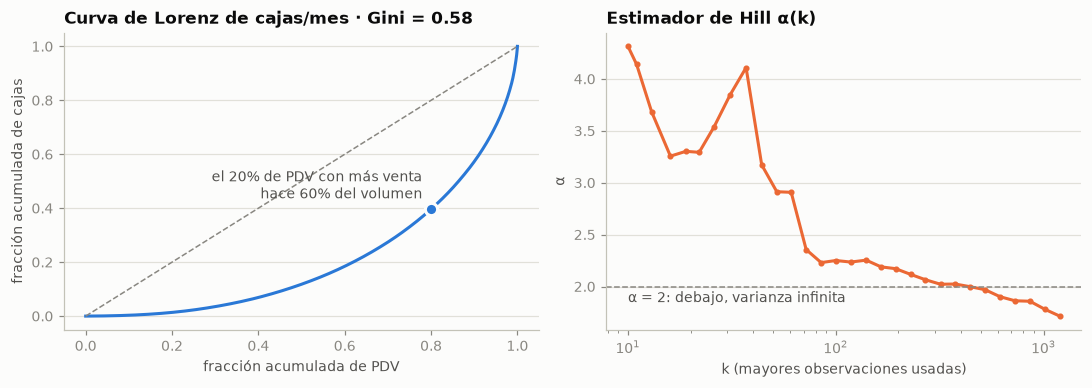

In [8]:
x_vida = pdv.cajas_mes_vida.to_numpy()
ajuste = eda.ajuste_distribuciones(x_vida)
display(ajuste)
lam = stats.boxcox(x_vida)[1]
print(f"Box-Cox λ (máx. verosimilitud) = {lam:.3f} → {'≈ log (λ ≈ 0): log1p es la transformación adecuada' if abs(lam) < 0.25 else 'usar Box-Cox'}")
curva_hill = eda.hill_curva(x_vida)
meseta = curva_hill[(curva_hill.index >= 50) & (curva_hill.index <= 400)]
print(f"Hill α para k = 50–400: mediana {meseta.median():.2f}, rango {meseta.min():.2f}–{meseta.max():.2f} | "
      f"para todo k: {curva_hill.min():.2f}–{curva_hill.max():.2f} (sin meseta limpia: la cola está en el límite α ≈ 2)")

fx, fy = eda.lorenz(x_vida)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(fx, fy, color=eda.PALETA[0])
ax[0].plot([0, 1], [0, 1], color=eda.MUTED, lw=1, ls="--")
top20 = 1 - np.interp(0.8, fx, fy)
ax[0].plot([0.8], [np.interp(0.8, fx, fy)], "o", color=eda.PALETA[0], ms=8, mec=eda.FONDO, mew=2)
ax[0].text(0.78, np.interp(0.8, fx, fy) + 0.04, f"el 20% de PDV con más venta\nhace {top20:.0%} del volumen", ha="right", color=eda.TINTA_2)
ax[0].set(title=f"Curva de Lorenz de cajas/mes · Gini = {eda.gini(x_vida):.2f}", xlabel="fracción acumulada de PDV",
          ylabel="fracción acumulada de cajas")
ax[1].plot(curva_hill.index, curva_hill.values, color=eda.PALETA[1], marker="o", ms=3)
ax[1].axhline(2, color=eda.MUTED, lw=1, ls="--")
ax[1].text(curva_hill.index.min(), 1.85, "α = 2: debajo, varianza infinita", ha="left", color=eda.TINTA_2)
ax[1].set(title="Estimador de Hill α(k)", xlabel="k (mayores observaciones usadas)", ylabel="α", xscale="log")
plt.tight_layout(); plt.show()

### 4.3 Atípicos de volumen (z robusto sobre log1p)

Mahalanobis no sirve aquí: `meses_activos` y `tasa_actividad` están acotadas (1–23, 0–1) y son discretas, y la
covarianza robusta sale degenerada (marca a la mitad de la base). Se usa el z modificado de Iglewicz-Hoaglin sobre
`log1p(cajas_mes_vida)`, la escala donde la distribución es aproximadamente simétrica (Box-Cox λ ≈ 0): |z| > 3.5.

In [9]:
pdv["z_robusto"] = eda.z_robusto(np.log1p(pdv.cajas_mes_vida))
pdv["atipico_volumen"] = pdv.z_robusto.abs() > 3.5
top = pdv[pdv.atipico_volumen].sort_values("cajas_mes_vida", ascending=False)
print(f"Atípicos de volumen: {pdv.atipico_volumen.sum():,} ({pdv.atipico_volumen.mean():.1%})")
display(top[["pos_name", "pos_subchannel", "cajas_mes_vida", "meses_activos", "z_robusto"]].head(15))

Atípicos de volumen: 8 (0.1%)


,pos_name,pos_subchannel,cajas_mes_vida,meses_activos,z_robusto
pos_id_cp,,,,,
405159,2251 FARMACIAS GUADALAJARA 65 CENTRO,FARMACIAS,119.807,23,4.466
448327,FARMACIAS DE AHORRO 58,FARMACIAS,71.914,23,3.852
435416,2491 FARMACIA GUADALAJARA CINCO COLONIAS,FARMACIAS,67.473,23,3.775
441067,FARMACIA GUADALAJARA CUIDAD CAUCEL,FARMACIAS,66.920,23,3.765
436125,FARMACIAS GUADALAJARA BOJORQUEZ,FARMACIAS,63.167,23,3.696
441500,2565 FARMACIAS GUADALAJARA KANASIN,FARMACIAS,60.331,23,3.641
10030,SAN GABRIEL,ABARRROTES,55.540,23,3.542
399260,2206 FARMACIA GUADALAJARA CANEK,FARMACIAS,54.208,23,3.513


**Lectura:** los atípicos son sucursales de cadenas de farmacias y PDV de alto tráfico, no errores: se **marcan** y se
conservan. En el 04 se reporta la mediana por área además de la suma, porque uno de ellos domina la suma de su zona.

### 4.4 Permanencia de los PDV (Kaplan-Meier)

Evento = el PDV deja de comprar (recencia ≥ 3 meses al cierre). Duración = meses entre su primera y su última venta si
ocurrió el evento; si sigue comprando (o lleva 1–2 meses sin comprar) la observación está **censurada** en su vida
hasta el cierre. S(t) = probabilidad de seguir comprando t meses después de la primera venta. IC95 de Greenwood.

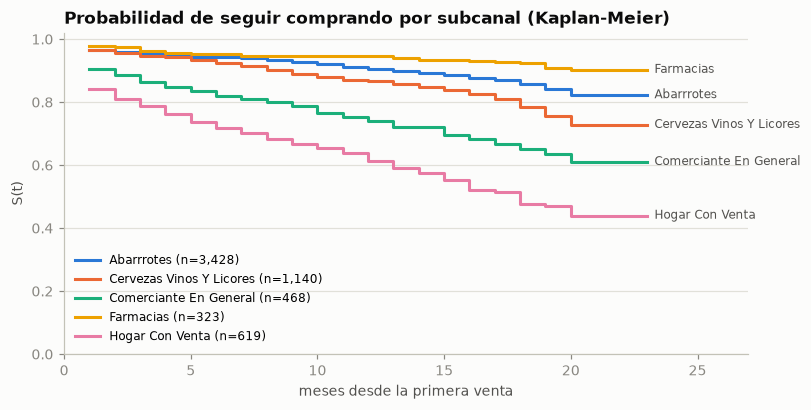

t,6,12,18,23
S(t) total,0.907,0.857,0.796,0.758
ABARRROTES,0.943,0.904,0.858,0.824
CERVEZAS VINOS Y LICORES,0.924,0.867,0.784,0.728
COMERCIANTE EN GENERAL,0.821,0.739,0.652,0.611
FARMACIAS,0.953,0.947,0.924,0.903
HOGAR CON VENTA,0.717,0.612,0.478,0.440


In [10]:
evento = pdv.recencia_meses >= 3
duracion = np.where(evento, pdv.meses_span, pdv.meses_vida)
km = eda.kaplan_meier(duracion, evento)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
supervivencia = {}
for i, (sc, g) in enumerate(pdv.groupby("pos_subchannel")):
    e = g.recencia_meses >= 3
    k_ = eda.kaplan_meier(np.where(e, g.meses_span, g.meses_vida), e)
    supervivencia[sc] = k_.S
    ax.step(k_.index, k_.S, where="post", color=eda.PALETA[i], label=f"{sc.title()} (n={len(g):,})")
    ax.text(k_.index.max() + 0.3, k_.S.iloc[-1], sc.title(), color=eda.TINTA_2, va="center", fontsize=8)
ax.set(title="Probabilidad de seguir comprando por subcanal (Kaplan-Meier)", xlabel="meses desde la primera venta",
       ylabel="S(t)", ylim=(0, 1.02), xlim=(0, 27))
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()
hitos = km.S.reindex(range(1, 24)).ffill().loc[[6, 12, 18, 23]]
display(pd.DataFrame({"S(t) total": hitos, **{k: v.reindex(range(1, 24)).ffill().loc[[6, 12, 18, 23]] for k, v in supervivencia.items()}}).T.round(3))

### 4.5 Canal Moderno vs Tradicional de los PDV

Mismo criterio que las tiendas DENUE (`src/cadenas.py`): **Moderno** = cadena identificada por nombre (farmacias de
cadena, Modelorama, tiendas de conveniencia…); **Tradicional** = independientes y Six. La venta se compara **dentro
del mismo subcanal** (el subcanal ya cambia la escala), con Mann-Whitney y δ de Cliff.

In [11]:
cp_zm = cp[cp.en_zm]
canal_tab = pd.crosstab([cp_zm.canal, cp_zm.pos_subchannel], cp_zm.pos_id.isin(pdv.index).rename("con venta"), margins=True)
display(canal_tab)
display(cp_zm[cp_zm.canal == "Moderno"].groupby("cadena").agg(PDV=("pos_id", "size"), con_venta=("pos_id", lambda x: x.isin(pdv.index).sum()))
        .sort_values("PDV", ascending=False))
comp_canal = []
for sc, g in pdv.groupby("pos_subchannel"):
    mo, tr = g.loc[g.canal == "Moderno", "cajas_mes_vida"], g.loc[g.canal == "Tradicional", "cajas_mes_vida"]
    if len(mo) >= 20 and len(tr) >= 20:
        comp_canal.append({"subcanal": sc, "n Moderno": len(mo), "n Tradicional": len(tr), "mediana Moderno": mo.median(),
                           "mediana Tradicional": tr.median(), "cliff_delta (M vs T)": eda.cliff_delta(mo, tr),
                           "p": stats.mannwhitneyu(mo, tr).pvalue})
comp_canal = pd.DataFrame(comp_canal)
if len(comp_canal):
    comp_canal["q_BH"] = stats.false_discovery_control(comp_canal.p, method="bh")
display(comp_canal)

con venta                             False  True   All
canal       pos_subchannel                             
Moderno     ABARRROTES                    0     2     2
            CERVEZAS VINOS Y LICORES     36   111   147
            COMERCIANTE EN GENERAL        2     0     2
            FARMACIAS                     9   256   265
            HOGAR CON VENTA               0     2     2
Tradicional ABARRROTES                  334  3426  3760
            CERVEZAS VINOS Y LICORES    158  1029  1187
            COMERCIANTE EN GENERAL      378   468   846
            FARMACIAS                    35    67   102
            HOGAR CON VENTA             525   617  1142
All                                    1477  5978  7455

,PDV,con_venta
cadena,,
Modelorama,148,112
Farmacias Yza,109,108
Farmacias Bazar,67,67
Farmacias Guadalajara,50,50
Farmacias del Ahorro,17,17
Farmacias Emérita,12,8
Farmacias Montejo,6,3
Farmacias Benavides,3,3
Super Aki,2,1


,subcanal,n Moderno,n Tradicional,mediana Moderno,mediana Tradicional,cliff_delta (M vs T),p,q_BH
0,CERVEZAS VINOS Y LICORES,111,1029,1.479,1.941,-0.179,0.002,0.002
1,FARMACIAS,256,67,4.474,1.654,0.443,0.000,0.000


## 5. Señales del CP: ¿cuáles aportan información?

Tres tipos de problema a descartar antes de usar una columna: **redundancia** (duplica otra), **fuga** (es una función
de la propia venta) y **ruido** (no se asocia con nada).

In [12]:
pot = ["PotentialQuantitative", "PotentialEstimatedToCover", "PotentialQuantitativeFinal"]
red = pd.DataFrame([{"señal": p, "TotalPortafolio = sueros (%)": np.isclose(cp[f"{p}_TotalPortafolio"], cp[f"{p}_CustomCat_sueros"]).mean() * 100,
                     "spearman": stats.spearmanr(cp[f"{p}_TotalPortafolio"], cp[f"{p}_CustomCat_sueros"], nan_policy="omit")[0]} for p in pot])
display(red)
x = cp.set_index("pos_id")
print("Identidad PotentialQuantitativeFinal = Quantitative × EstimatedToCover:",
      bool(np.allclose(x.PotentialQuantitativeFinal_TotalPortafolio, x.PotentialQuantitative_TotalPortafolio * x.PotentialEstimatedToCover_TotalPortafolio, equal_nan=True)))
cruce = pdv.join(x.drop(columns=["pos_name", "pos_subchannel", "pos_size_classification", "cadena", "canal"]), how="left")
rel = (cruce.PotentialQuantitative_TotalPortafolio / cruce.cajas_mes_activo - 1).abs()
print(f"PotentialQuantitative vs cajas_mes_activo: |diferencia relativa| mediana {rel.median():.4f}, p95 {rel.quantile(.95):.4f}; "
      f"idénticas (±0.01 cajas) en {np.isclose(cruce.PotentialQuantitative_TotalPortafolio, cruce.cajas_mes_activo, atol=0.011).mean():.1%}")
print("Comparative_Client_ID apunta a otro PDV del CP:", f"{cruce.Comparative_Client_ID_TotalPortafolio.isin(cp.pos_id).mean():.1%}",
      f"| es el mismo PDV: {(cruce.Comparative_Client_ID_TotalPortafolio == cruce.index).mean():.1%}")
cp = cp[cp.en_zm].copy()                        # desde aquí, universo = CP de la ZM

,señal,TotalPortafolio = sueros (%),spearman
0,PotentialQuantitative,81.479,0.998
1,PotentialEstimatedToCover,75.073,0.998
2,PotentialQuantitativeFinal,75.070,0.998


Identidad PotentialQuantitativeFinal = Quantitative × EstimatedToCover: True
PotentialQuantitative vs cajas_mes_activo: |diferencia relativa| mediana 0.0007, p95 0.0034; idénticas (±0.01 cajas) en 99.3%
Comparative_Client_ID apunta a otro PDV del CP: 100.0% | es el mismo PDV: 5.3%


### 5.1 Prueba de fuga: ¿se puede reconstruir la columna solo con la venta?

Un árbol de decisión con **una sola variable** (cajas/mes activo) predice cada columna categórica; exactitud por
validación cruzada de 5 pliegues. Exactitud ≈ 100% = la columna es una función de la venta (fuga). Referencia: la
exactitud de adivinar siempre la clase más frecuente.

In [13]:
fuga = []
for c in ["size_class", "pos_size_classification", "PotentialQualitative_TotalPortafolio", "pos_subchannel", "cluster"]:
    d = cruce[[c, "cajas_mes_activo"]].dropna()
    acc = cross_val_score(DecisionTreeClassifier(max_depth=4, random_state=eda.SEMILLA), d[["cajas_mes_activo"]], d[c].astype(str), cv=5)
    fuga.append({"columna": c, "clases": d[c].nunique(), "exactitud_CV": acc.mean(), "±": acc.std(),
                 "línea base (clase mayoritaria)": d[c].astype(str).value_counts(normalize=True).iloc[0]})
fuga = pd.DataFrame(fuga)
fuga["veredicto"] = np.where(fuga.exactitud_CV > 0.95, "FUGA: función de la venta",
                    np.where(fuga.exactitud_CV - fuga["línea base (clase mayoritaria)"] > 0.1, "asociada a la venta", "poco asociada"))
display(fuga)
display(cruce.groupby("size_class").cajas_mes_activo.agg(["count", "min", "max"]).sort_values("min"))

,columna,clases,exactitud_CV,±,línea base (clase mayoritaria),veredicto
0,size_class,5,0.975,0.009,0.202,FUGA: función de la venta
1,pos_size_classification,3,0.600,0.009,0.426,asociada a la venta
2,PotentialQualitative_TotalPortafolio,4,0.457,0.001,0.449,poco asociada
3,pos_subchannel,5,0.568,0.025,0.573,poco asociada
4,cluster,7,0.529,0.003,0.532,poco asociada


,count,min,max
size_class,,,
muy pequeño,1189,0.528,1.849
pequeño,1181,0.927,2.889
mediano,1207,1.387,4.411
grande,1200,1.849,8.689
muy grande,1201,3.280,119.807


### 5.1b ¿La clase de potencial del CP depende del tamaño actual de la tienda?

El árbol de arriba mide si la clase se **reconstruye** con la venta (exactitud vs clase mayoritaria); no detecta que
ciertas clases **solo existan** en tiendas grandes. Por construcción `PotentialQuantitativeFinal` = `PotentialQuantitative`
(≈ venta actual) × `PotentialEstimatedToCover` (brecha relativa vs el comparable), así que el potencial *absoluto* escala con
la venta actual. Se cruza la clase con los deciles de venta y se prueba la independencia (χ², V de Cramér); la **brecha
relativa** es la parte del CP que no depende del tamaño.

In [14]:
dec = pd.qcut(cruce.cajas_mes_activo.rank(method="first"), 10, labels=[f"D{i}" for i in range(1, 11)])
t_cls = pd.crosstab(dec, cruce.PotentialQualitative_TotalPortafolio).reindex(columns=["Low", "Moderate", "High", "Very High"]).fillna(0).astype(int)
chi = stats.chi2_contingency(t_cls)
vh_inf = t_cls.loc[[f"D{i}" for i in range(1, 6)], "Very High"].sum() / t_cls["Very High"].sum()
etc = cruce[["PotentialEstimatedToCover_TotalPortafolio", "cajas_mes_activo"]].dropna()
rho_etc = stats.spearmanr(etc.iloc[:, 0], etc.iloc[:, 1])
rho_fin = stats.spearmanr(*cruce[["PotentialQuantitativeFinal_TotalPortafolio", "cajas_mes_activo"]].dropna().T.values)
clase_tamano = (f"Very High: {vh_inf:.0%} de sus tiendas en la mitad inferior de venta (D1–D5); χ² p = {chi.pvalue:.0e}, "
                f"V de Cramér = {eda.cramer_v(t_cls):.2f}. Potencial final vs venta ρ = {rho_fin[0]:+.2f}; brecha relativa vs venta ρ = {rho_etc[0]:+.2f}.")
print(clase_tamano)
display(t_cls)

Very High: 0% de sus tiendas en la mitad inferior de venta (D1–D5); χ² p = 5e-284, V de Cramér = 0.28. Potencial final vs venta ρ = +0.23; brecha relativa vs venta ρ = -0.15.


PotentialQualitative_TotalPortafolio,Low,Moderate,High,Very High
cajas_mes_activo,,,,
D1,339,256,3,0
D2,361,217,20,0
D3,308,236,54,0
D4,313,233,51,0
D5,254,232,112,0
D6,279,208,109,2
D7,207,190,179,21
D8,254,175,140,29
D9,121,151,197,129


### 5.2 Dependencia con la venta: Spearman con IC95, Pearson sobre log1p e información mutua (q de BH)

In [15]:
num = ["PotentialQuantitative_TotalPortafolio", "PotentialEstimatedToCover_TotalPortafolio",
       "PotentialQuantitativeFinal_TotalPortafolio", "area", "cluster"]
dep = eda.dependencias(cruce, num, ["cajas_mes_vida", "cajas_mes_activo", "tasa_actividad"])
display(dep)

,x,y,n,spearman,IC95,pearson_log1p,p,MI,q_BH,significativa,no_monotona
0,PotentialQuantitative_TotalPortafolio,cajas_mes_activo,5978,0.999,"[+1.00, +1.00]",0.999,0.000,6.140,0.000,True,False
1,PotentialQuantitative_TotalPortafolio,cajas_mes_vida,5978,0.951,"[+0.95, +0.95]",0.960,0.000,2.716,0.000,True,False
2,PotentialQuantitative_TotalPortafolio,tasa_actividad,5978,0.713,"[+0.70, +0.73]",0.597,0.000,0.426,0.000,True,False
3,PotentialQuantitativeFinal_TotalPortafolio,cajas_mes_activo,5978,0.231,"[+0.20, +0.26]",0.376,0.000,0.192,0.000,True,False
4,PotentialQuantitativeFinal_TotalPortafolio,cajas_mes_vida,5978,0.221,"[+0.20, +0.25]",0.368,0.000,0.157,0.000,True,False
5,PotentialQuantitativeFinal_TotalPortafolio,tasa_actividad,5978,0.174,"[+0.15, +0.20]",0.239,0.000,0.056,0.000,True,False
6,PotentialEstimatedToCover_TotalPortafolio,cajas_mes_activo,5978,-0.149,"[-0.18, -0.12]",-0.134,0.000,0.041,0.000,True,False
7,PotentialEstimatedToCover_TotalPortafolio,cajas_mes_vida,5978,-0.138,"[-0.16, -0.11]",-0.122,0.000,0.024,0.000,True,False
8,PotentialEstimatedToCover_TotalPortafolio,tasa_actividad,5978,-0.098,"[-0.12, -0.07]",-0.093,0.000,0.000,0.000,True,False
9,area,cajas_mes_activo,5978,0.057,"[+0.03, +0.08]",0.065,0.000,0.000,0.000,True,False


### 5.3 ¿La asociación se sostiene dentro de cada subcanal? (control de la paradoja de Simpson)

Si una señal solo "funciona" en el agregado porque los subcanales tienen niveles distintos de venta y de potencial,
no sirve para comparar PDV. Se repite el Spearman dentro de cada subcanal con IC95.

In [16]:
estr = []
for sc, g in cruce.groupby("pos_subchannel"):
    for s in ["PotentialQuantitativeFinal_TotalPortafolio", "PotentialEstimatedToCover_TotalPortafolio", "area"]:
        d = g[[s, "cajas_mes_vida"]].dropna()
        r, p = stats.spearmanr(d[s], d.cajas_mes_vida)
        lo, hi = eda.spearman_ic(r, len(d))
        estr.append({"subcanal": sc, "señal": s, "n": len(d), "spearman": r, "IC95": f"[{lo:+.2f}, {hi:+.2f}]", "p": p})
estr = pd.DataFrame(estr)
estr["q_BH"] = stats.false_discovery_control(estr.p, method="bh")
display(estr.pivot_table(index="señal", columns="subcanal", values="spearman").round(2))
display(estr)

subcanal,ABARRROTES,CERVEZAS VINOS Y LICORES,COMERCIANTE EN GENERAL,FARMACIAS,HOGAR CON VENTA
señal,,,,,
PotentialEstimatedToCover_TotalPortafolio,-0.100,-0.170,-0.280,-0.160,-0.240
PotentialQuantitativeFinal_TotalPortafolio,0.250,0.100,0.040,0.230,0.020
area,0.030,0.030,0.140,0.050,0.000


,subcanal,señal,n,spearman,IC95,p,q_BH
0,ABARRROTES,PotentialQuantitativeFinal_TotalPortafolio,3428,0.254,"[+0.22, +0.29]",0.000,0.000
1,ABARRROTES,PotentialEstimatedToCover_TotalPortafolio,3428,-0.103,"[-0.14, -0.07]",0.000,0.000
2,ABARRROTES,area,3428,0.027,"[-0.01, +0.06]",0.110,0.166
3,CERVEZAS VINOS Y LICORES,PotentialQuantitativeFinal_TotalPortafolio,1140,0.104,"[+0.04, +0.16]",0.000,0.001
4,CERVEZAS VINOS Y LICORES,PotentialEstimatedToCover_TotalPortafolio,1140,-0.169,"[-0.23, -0.11]",0.000,0.000
5,CERVEZAS VINOS Y LICORES,area,1140,0.032,"[-0.03, +0.09]",0.273,0.372
6,COMERCIANTE EN GENERAL,PotentialQuantitativeFinal_TotalPortafolio,468,0.037,"[-0.06, +0.13]",0.420,0.485
7,COMERCIANTE EN GENERAL,PotentialEstimatedToCover_TotalPortafolio,468,-0.285,"[-0.37, -0.19]",0.000,0.000
8,COMERCIANTE EN GENERAL,area,468,0.139,"[+0.04, +0.23]",0.003,0.005
9,FARMACIAS,PotentialQuantitativeFinal_TotalPortafolio,323,0.230,"[+0.12, +0.34]",0.000,0.000


### 5.4 Variables categóricas: Kruskal-Wallis con ε² (IC95 bootstrap) y comparaciones por pares (δ de Cliff)

,variable,niveles,n,H,p,epsilon2,IC95,q_BH
0,size_class,5,5978,"5,168.029",0.000,0.865,"[0.856, 0.873]",0.000
1,pos_size_classification,3,5978,"2,611.416",0.000,0.437,"[0.421, 0.455]",0.000
2,PotentialQualitative_TotalPortafolio,4,5978,926.668,0.000,0.155,"[0.144, 0.168]",0.000
3,pos_subchannel,5,5978,847.394,0.000,0.141,"[0.127, 0.158]",0.000
4,cluster,7,5969,19.723,0.003,0.002,"[0.001, 0.007]",0.003


,A,B,mediana_A,mediana_B,cliff_delta,p,q_BH,efecto
0,FARMACIAS,HOGAR CON VENTA,3.975,0.528,0.723,0.000,0.000,grande
1,ABARRROTES,HOGAR CON VENTA,2.704,0.528,0.594,0.000,0.000,grande
2,COMERCIANTE EN GENERAL,FARMACIAS,0.955,3.975,-0.580,0.000,0.000,grande
3,CERVEZAS VINOS Y LICORES,HOGAR CON VENTA,1.876,0.528,0.492,0.000,0.000,grande
4,CERVEZAS VINOS Y LICORES,FARMACIAS,1.876,3.975,-0.431,0.000,0.000,medio
5,ABARRROTES,COMERCIANTE EN GENERAL,2.704,0.955,0.410,0.000,0.000,medio
6,CERVEZAS VINOS Y LICORES,COMERCIANTE EN GENERAL,1.876,0.955,0.269,0.000,0.000,chico
7,ABARRROTES,FARMACIAS,2.704,3.975,-0.244,0.000,0.000,chico
8,ABARRROTES,CERVEZAS VINOS Y LICORES,2.704,1.876,0.207,0.000,0.000,chico
9,COMERCIANTE EN GENERAL,HOGAR CON VENTA,0.955,0.528,0.203,0.000,0.000,chico


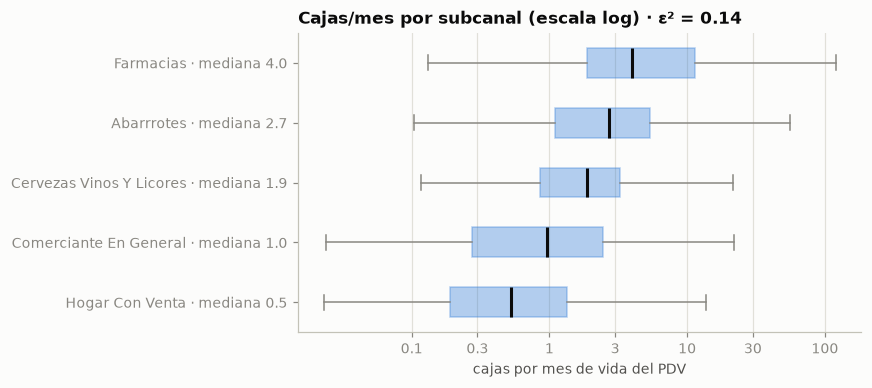

In [17]:
cats = ["pos_subchannel", "size_class", "pos_size_classification", "cluster", "PotentialQualitative_TotalPortafolio"]
cat = eda.efecto_categorico(cruce, cats, "cajas_mes_vida")
display(cat)
pares = eda.comparaciones_pares(cruce, "pos_subchannel", "cajas_mes_vida")
display(pares)

orden = cruce.groupby("pos_subchannel").cajas_mes_vida.median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 3.6))
datos = [np.log10(cruce.loc[cruce.pos_subchannel == s, "cajas_mes_vida"]) for s in orden]
bp = ax.boxplot(datos, orientation="horizontal", widths=0.5, patch_artist=True, showfliers=False,
                medianprops=dict(color=eda.TINTA, lw=2), whiskerprops=dict(color=eda.MUTED), capprops=dict(color=eda.MUTED))
for patch in bp["boxes"]:
    patch.set(facecolor=eda.PALETA[0], alpha=0.35, edgecolor=eda.PALETA[0])
ax.set_yticks(range(1, len(orden) + 1), [f"{s.title()} · mediana {10 ** np.median(d):.1f}" for s, d in zip(orden, datos)])
ticks = [0.1, 0.3, 1, 3, 10, 30, 100]
ax.set_xticks(np.log10(ticks), [str(t) for t in ticks])
ax.set(title=f"Cajas/mes por subcanal (escala log) · ε² = {cat.set_index('variable').loc['pos_subchannel', 'epsilon2']:.2f}",
       xlabel="cajas por mes de vida del PDV")
ax.grid(axis="x", color=eda.GRID); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 6. Veredicto: qué señales sirven

Tabla de decisión con la estadística que la respalda (se usa en el notebook 04).

In [18]:
def rho(xc, yc="cajas_mes_vida"):
    r = dep[(dep.x == xc) & (dep.y == yc)]
    return f"ρ={r.spearman.iloc[0]:+.2f} {r.IC95.iloc[0]}" if len(r) else "—"
def eps(c):
    r = cat[cat.variable == c]
    return f"ε²={r.epsilon2.iloc[0]:.3f} {r.IC95.iloc[0]}" if len(r) else "—"
def acc(c):
    r = fuga[fuga.columna == c]
    return f"exactitud con solo la venta {r.exactitud_CV.iloc[0]:.1%}" if len(r) else "—"
def rng_estr(s):
    g = estr[estr.señal == s]
    si, no = g[g.q_BH < 0.05], g[g.q_BH >= 0.05]
    txt = "significativo en " + ", ".join(f"{r.subcanal.title()} {r.spearman:+.2f}" for r in si.itertuples()) if len(si) else "no significativo en ningún subcanal"
    return txt + ("; nulo en " + ", ".join(r.subcanal.title() for r in no.itertuples()) if len(no) else "")

senales = pd.DataFrame([
    ("cajas_mes_vida (ventas)", "USAR · variable objetivo", f"intensidad sobre la vida del PDV; Box-Cox λ = {lam:.2f} → analizar en log1p"),
    ("estado_actividad / recencia", "USAR", f"{(pdv.recencia_meses > 0).mean():.0%} no compró en el último mes; S(12 m) = {hitos.loc[12]:.2f}"),
    ("tasa_actividad", "USAR", "regularidad de compra (meses activos / meses de vida)"),
    ("cajas_mes_activo (= avg_monthly_boxes)", "USAR CON CUIDADO", "sesgado al alza en PDV intermitentes o inactivos"),
    ("PotentialQuantitative_*", "NO USAR · fuga", f"es la venta mensual actual: |dif. relativa| mediana {rel.median():.4f}"),
    ("PotentialQuantitativeFinal_*", "USAR · clasificar (potencial futuro, no decisivo)", f"Quantitative × EstimatedToCover; {rho('PotentialQuantitativeFinal_TotalPortafolio')}; dentro de subcanal {rng_estr('PotentialQuantitativeFinal_TotalPortafolio')}"),
    ("PotentialEstimatedToCover_*", "USAR", f"brecha vs PDV comparable; {rho('PotentialEstimatedToCover_TotalPortafolio')}"),
    ("PotentialRange / PotentialQualitative", "USAR · clase de potencial futuro (clasificación), leer junto al tamaño",
     f"clase Very High → Low del potencial absoluto; clasifica, no decide; {acc('PotentialQualitative_TotalPortafolio')}; {clase_tamano}"),
    ("columnas *_CustomCat_sueros", "REDUNDANTE", "≈ *_TotalPortafolio (ρ ≈ 1): la venta solo trae la categoría sueros"),
    ("Comparative_Client_ID_*", "SOLO TRAZABILIDAD", "PDV de referencia usado para el potencial; no es predictor"),
    ("pos_subchannel", "USAR · segmentar", f"{eps('pos_subchannel')}; comparar PDV dentro de su subcanal"),
    ("canal (Moderno / Tradicional)", "USAR · entregar por separado", f"{(cp_zm.canal == 'Moderno').sum():,} PDV Moderno de {len(cp_zm):,}; misma regla que DENUE (src/cadenas.py)"),
    ("size_class", "NO USAR · fuga", f"{eps('size_class')}; {acc('size_class')}: son cortes de la propia venta"),
    ("pos_size_classification", "USAR", f"{eps('pos_size_classification')}; {acc('pos_size_classification')}; existe para todo el CP"),
    ("cluster", "RUIDO", f"{eps('cluster')}; {rho('cluster')}; sin diccionario"),
    ("area", "SEÑAL DÉBIL", f"{rho('area')}; dentro de subcanal {rng_estr('area')}; unidad desconocida (máx {cp.area.max():,.0f})"),
    ("lat / lon", "USAR (limpias)", f"{(cp.coord_estado == 'corregida').sum()} corregidas en la ZM; municipio asignado por polígono"),
], columns=["señal", "veredicto", "evidencia"])
with pd.option_context("display.max_colwidth", None):
    display(senales)

,señal,veredicto,evidencia
0,cajas_mes_vida (ventas),USAR · variable objetivo,intensidad sobre la vida del PDV; Box-Cox λ = 0.15 → analizar en log1p
1,estado_actividad / recencia,USAR,38% no compró en el último mes; S(12 m) = 0.86
2,tasa_actividad,USAR,regularidad de compra (meses activos / meses de vida)
3,cajas_mes_activo (= avg_monthly_boxes),USAR CON CUIDADO,sesgado al alza en PDV intermitentes o inactivos
4,PotentialQuantitative_*,NO USAR · fuga,es la venta mensual actual: |dif. relativa| mediana 0.0007
5,PotentialQuantitativeFinal_*,"USAR · clasificar (potencial futuro, no decisivo)","Quantitative × EstimatedToCover; ρ=+0.22 [+0.20, +0.25]; dentro de subcanal significativo en Abarrrotes +0.25, Cervezas Vinos Y Licores +0.10, Farmacias +0.23; nulo en Comerciante En General, Hogar Con Venta"
6,PotentialEstimatedToCover_*,USAR,"brecha vs PDV comparable; ρ=-0.14 [-0.16, -0.11]"
7,PotentialRange / PotentialQualitative,"USAR · clase de potencial futuro (clasificación), leer junto al tamaño","clase Very High → Low del potencial absoluto; clasifica, no decide; exactitud con solo la venta 45.7%; Very High: 0% de sus tiendas en la mitad inferior de venta (D1–D5); χ² p = 5e-284, V de Cramér = 0.28. Potencial final vs venta ρ = +0.23; brecha relativa vs venta ρ = -0.15."
8,columnas *_CustomCat_sueros,REDUNDANTE,≈ *_TotalPortafolio (ρ ≈ 1): la venta solo trae la categoría sueros
9,Comparative_Client_ID_*,SOLO TRAZABILIDAD,PDV de referencia usado para el potencial; no es predictor


## 7. Hallazgos

Resumen de todo lo encontrado, con el número que lo respalda (se recalcula en cada corrida) y qué implica para el 04.

In [19]:
act = pdv.estado_actividad.value_counts(normalize=True)
sub = cruce.groupby("pos_subchannel").cajas_mes_vida.median().sort_values()
n_cp_zm, n_venta_zm = len(cp), int(cp.pos_id.isin(pdv.index).sum())
mejor = ajuste.iloc[0]
par_top = pares.iloc[0]
hallazgos = pd.DataFrame([
    ("Llave", f"ID de ventas = prefijo de 4 dígitos (centro de distribución) + pos_id del CP. Empata {k / n:.1%} (IC95 {ic.low:.1%}–{ic.high:.1%}) "
              f"vs {densidad:.1%} por azar (binomial p = {binom.pvalue:.0e}); pureza geográfica {real:.2f} vs {perm:.2f} permutada (p = {p_perm:.3f}).",
     "Inferida de los datos: confirmar con Bepensa."),
    ("Cobertura ZM", f"{n_cp_zm:,} PDV del CP en {C.ZM_NOMBRE}; {n_venta_zm:,} con venta ({n_venta_zm / n_cp_zm:.0%}) y "
                     f"{n_cp_zm - n_venta_zm:,} sin venta (prospectos, sin potencial calculado: V de Cramér = {eda.cramer_v(t_mnar):.2f}).",
     "Los PDV sin venta sirven para medir penetración en el área."),
    ("Ventas sin ubicar (sesgo)", f"En los prefijos de la ZM {len(a):,} registros no empatan y concentran {sesgo['% de las cajas'].iloc[0]:.1f}% de las cajas. "
                                  f"El registro típico casi no difiere del analizado (δ de Cliff = {d_sesgo:+.2f}; mediana {sesgo['mediana cajas/mes activo'].iloc[0]:.1f} vs "
                                  f"{sesgo['mediana cajas/mes activo'].iloc[1]:.1f} cajas/mes), pero el 10% más grande de ellos hace {top10_sin:.0%} de sus cajas: "
                                  f"son pocas cuentas muy grandes ({sesgo['% prefijo 3xxx'].iloc[0]:.0f}% con prefijo 3xxx).",
     "El 04 describe bien al PDV típico, pero no el volumen total: pedir a Bepensa la tabla de equivalencias o coordenadas de esas cuentas."),
    ("PotentialQuantitative = venta actual", f"|dif. relativa| con cajas_mes_activo: mediana {rel.median():.4f}; idénticas en "
                                             f"{np.isclose(cruce.PotentialQuantitative_TotalPortafolio, cruce.cajas_mes_activo, atol=0.011).mean():.1%}.",
     "Fuga: no usar como potencial ni como predictor."),
    ("CP: potencial futuro", f"PotentialQuantitativeFinal = Quantitative × EstimatedToCover; {rho('PotentialQuantitativeFinal_TotalPortafolio')} con la venta y "
                              f"dentro de subcanal: {rng_estr('PotentialQuantitativeFinal_TotalPortafolio')}.",
     "Mide el potencial futuro de cada cliente frente a su comparable: variable de CLASIFICACIÓN (clase Very High → Low), no decisiva. En el 05 acompaña a los clústeres Golden Stores."),
    ("Clase CP y tamaño", clase_tamano,
     "La clase mide potencial ABSOLUTO (venta actual × brecha): las clases altas solo aparecen en tiendas que ya venden. Sigue siendo variable de "
     "clasificación; para comparar tiendas de distinto tamaño usar la brecha relativa (PotentialEstimatedToCover), que va en el Excel del 05."),
    ("size_class", f"{acc('size_class')} (línea base {fuga.set_index('columna').loc['size_class', 'línea base (clase mayoritaria)']:.0%}); {eps('size_class')}.",
     "Fuga: son cortes de la propia venta. No usar."),
    ("Tamaño del PDV", f"pos_size_classification {eps('pos_size_classification')}; {acc('pos_size_classification')}; existe para todo el CP.", "Usar para segmentar."),
    ("Subcanal", f"{eps('pos_subchannel')}. Mediana de cajas/mes: " + " · ".join(f"{k_.title()} {v_:.1f}" for k_, v_ in sub.items()) +
                 f". Mayor diferencia: {par_top.A.title()} vs {par_top.B.title()} (δ = {par_top.cliff_delta:+.2f}, {par_top.efecto}).",
     "Comparar PDV siempre dentro de su subcanal."),
    ("Canal", f"{(cp_zm.canal == 'Moderno').sum():,} PDV Moderno ({(cp_zm.canal == 'Moderno').mean():.1%}) y {(cp_zm.canal == 'Tradicional').sum():,} Tradicional en la ZM. "
              f"Moderno = " + ", ".join(f"{k} {v}" for k, v in cp_zm[cp_zm.canal == 'Moderno'].cadena.value_counts().head(5).items()) + ". "
              + ("Dentro de subcanal: " + "; ".join(f"{r['subcanal'].title()} mediana M {r['mediana Moderno']:.1f} vs T {r['mediana Tradicional']:.1f} (δ = {r['cliff_delta (M vs T)']:+.2f})"
                                                    for _, r in comp_canal.iterrows()) if len(comp_canal) else ""),
     "El CP casi no tiene cadenas de conveniencia/autoservicio (OXXO, Walmart): probablemente son cuentas clave fuera del CP (ver 'Ventas sin ubicar')."),
    ("Actividad", f"Al cierre ({fin:%b-%Y}): activos {act.get('activo', 0):.0%} · en riesgo {act.get('en riesgo (1-2 m)', 0):.0%} · "
                  f"inactivos {act.get('inactivo (3+ m)', 0):.0%}. Kaplan-Meier: S(6 m) = {hitos.loc[6]:.2f}, S(12 m) = {hitos.loc[12]:.2f}, S(23 m) = {hitos.loc[23]:.2f}.",
     "avg_monthly_boxes sobreestima a los inactivos: usar cajas_mes_vida."),
    ("Distribución", f"Mejor ajuste por AIC: {mejor.familia} (siguiente a ΔAIC = {ajuste.ΔAIC.iloc[1]:.0f}); Box-Cox λ = {lam:.2f} (≈ log). "
                     f"Hill α ≈ {meseta.median():.2f} (entre {curva_hill.min():.2f} y {curva_hill.max():.2f} según k): cola en el límite de varianza infinita.",
     "Trabajar en log1p; reportar medianas con IC, no medias ± sd."),
    ("Concentración", f"Gini = {uni.loc['cajas_mes_vida', 'gini']:.2f}; el 20% de PDV con más venta hace {uni.loc['cajas_mes_vida', 'cuota_top20%']:.0f}% del volumen; "
                      f"mediana {uni.loc['cajas_mes_vida', 'mediana']:.2f} cajas/mes (IC95 {uni.loc['cajas_mes_vida', 'mediana_IC95']}).",
     "Por área, reportar suma y mediana."),
    ("Atípicos", f"{int(pdv.atipico_volumen.sum())} PDV con |z robusto| > 3.5 (sucursales de cadenas de farmacias): reales, se conservan marcados.",
     "Pueden dominar la venta de su área."),
    ("Coordenadas", f"Base completa: {(cp_total_estado == 'corregida').sum()} corregidas y {(cp_total_estado != 'original').sum() - (cp_total_estado == 'corregida').sum()} descartadas. "
                    f"En la ZM, {int((cp.municipio_mg.str.upper() != cp.pos_city.str.upper().str.replace('MERIDA', 'MÉRIDA')).sum()):,} PDV tienen pos_city distinto al municipio real "
                    f"y {int(dup.sum()):,} comparten coordenadas exactas con otro PDV.",
     "Usar el municipio del polígono, no pos_city."),
    ("Ruido", f"cluster {eps('cluster')}; area {rho('area')}.", "No usar sin su diccionario."),
], columns=["tema", "hallazgo", "implicación"])
with pd.option_context("display.max_colwidth", None):
    display(hallazgos)

,tema,hallazgo,implicación
0,Llave,ID de ventas = prefijo de 4 dígitos (centro de distribución) + pos_id del CP. Empata 73.3% (IC95 72.9%–73.8%) vs 3.7% por azar (binomial p = 0e+00); pureza geográfica 0.71 vs 0.16 permutada (p = 0.005).,Inferida de los datos: confirmar con Bepensa.
1,Cobertura ZM,"7,455 PDV del CP en ZM Mérida; 5,978 con venta (80%) y 1,477 sin venta (prospectos, sin potencial calculado: V de Cramér = 1.00).",Los PDV sin venta sirven para medir penetración en el área.
2,Ventas sin ubicar (sesgo),"En los prefijos de la ZM 1,720 registros no empatan y concentran 30.9% de las cajas. El registro típico casi no difiere del analizado (δ de Cliff = +0.13; mediana 3.6 vs 2.7 cajas/mes), pero el 10% más grande de ellos hace 58% de sus cajas: son pocas cuentas muy grandes (30% con prefijo 3xxx).","El 04 describe bien al PDV típico, pero no el volumen total: pedir a Bepensa la tabla de equivalencias o coordenadas de esas cuentas."
3,PotentialQuantitative = venta actual,|dif. relativa| con cajas_mes_activo: mediana 0.0007; idénticas en 99.3%.,Fuga: no usar como potencial ni como predictor.
4,CP: potencial futuro,"PotentialQuantitativeFinal = Quantitative × EstimatedToCover; ρ=+0.22 [+0.20, +0.25] con la venta y dentro de subcanal: significativo en Abarrrotes +0.25, Cervezas Vinos Y Licores +0.10, Farmacias +0.23; nulo en Comerciante En General, Hogar Con Venta.","Mide el potencial futuro de cada cliente frente a su comparable: variable de CLASIFICACIÓN (clase Very High → Low), no decisiva. En el 05 acompaña a los clústeres Golden Stores."
5,Clase CP y tamaño,"Very High: 0% de sus tiendas en la mitad inferior de venta (D1–D5); χ² p = 5e-284, V de Cramér = 0.28. Potencial final vs venta ρ = +0.23; brecha relativa vs venta ρ = -0.15.","La clase mide potencial ABSOLUTO (venta actual × brecha): las clases altas solo aparecen en tiendas que ya venden. Sigue siendo variable de clasificación; para comparar tiendas de distinto tamaño usar la brecha relativa (PotentialEstimatedToCover), que va en el Excel del 05."
6,size_class,"exactitud con solo la venta 97.5% (línea base 20%); ε²=0.865 [0.856, 0.873].",Fuga: son cortes de la propia venta. No usar.
7,Tamaño del PDV,"pos_size_classification ε²=0.437 [0.421, 0.455]; exactitud con solo la venta 60.0%; existe para todo el CP.",Usar para segmentar.
8,Subcanal,"ε²=0.141 [0.127, 0.158]. Mediana de cajas/mes: Hogar Con Venta 0.5 · Comerciante En General 1.0 · Cervezas Vinos Y Licores 1.9 · Abarrrotes 2.7 · Farmacias 4.0. Mayor diferencia: Farmacias vs Hogar Con Venta (δ = +0.72, grande).",Comparar PDV siempre dentro de su subcanal.
9,Canal,"418 PDV Moderno (5.6%) y 7,037 Tradicional en la ZM. Moderno = Modelorama 148, Farmacias Yza 109, Farmacias Bazar 67, Farmacias Guadalajara 50, Farmacias del Ahorro 17. Dentro de subcanal: Cervezas Vinos Y Licores mediana M 1.5 vs T 1.9 (δ = -0.18); Farmacias mediana M 4.5 vs T 1.7 (δ = +0.44)","El CP casi no tiene cadenas de conveniencia/autoservicio (OXXO, Walmart): probablemente son cuentas clave fuera del CP (ver 'Ventas sin ubicar')."


## 8. Guardar

In [20]:
salida = (cp.set_index("pos_id")
          .drop(columns=[c for c in cp.columns if c.endswith("_CustomCat_sueros")] + ["pos_latitude", "pos_longitude"])
          .join(pdv.drop(columns=["pos_name", "pos_subchannel", "pos_size_classification", "cadena", "canal"]), how="left"))
salida["con_venta"] = salida.cajas_total.notna()
salida.index.name = "pos_id_cp"
salida.reset_index().to_parquet(C.PROC / f"pdv_{C.CLIENTE}_{C.SLUG}.parquet", index=False)
vz[~vz.en_cp].to_parquet(C.PROC / f"ventas_sin_cp_{C.CLIENTE}_{C.SLUG}.parquet", index=False)

out = C.OUT / f"00_validacion_ventas_cp_{C.CLIENTE}_{C.SLUG}.xlsx"
with pd.ExcelWriter(out) as xw:
    hallazgos.to_excel(xw, sheet_name="Hallazgos", index=False)
    FUENTES_CLIENTE.to_excel(xw, sheet_name="Datos del cliente", index=False)
    senales.to_excel(xw, sheet_name="Señales", index=False)
    llave.to_excel(xw, sheet_name="Llave por prefijo")
    sesgo.to_excel(xw, sheet_name="Sesgo ventas sin ubicar", index=False)
    cp.coord_estado.value_counts().to_frame("PDV").to_excel(xw, sheet_name="Coordenadas")
    uni.to_excel(xw, sheet_name="Univariado")
    ajuste.to_excel(xw, sheet_name="Ajuste distribuciones", index=False)
    km.to_excel(xw, sheet_name="Kaplan-Meier")
    fuga.to_excel(xw, sheet_name="Prueba de fuga", index=False)
    dep.to_excel(xw, sheet_name="Dependencias", index=False)
    estr.to_excel(xw, sheet_name="Por subcanal", index=False)
    cat.to_excel(xw, sheet_name="Categoricas", index=False)
    pares.to_excel(xw, sheet_name="Pares subcanal", index=False)
    canal_tab.to_excel(xw, sheet_name="Canal")
    comp_canal.to_excel(xw, sheet_name="Canal por subcanal", index=False)
    top.to_excel(xw, sheet_name="Atipicos")
    vz[~vz.en_cp].sort_values("total_boxes_sold", ascending=False).to_excel(xw, sheet_name="Ventas sin ubicar", index=False)
print(f"Guardado: {C.PROC / f'pdv_{C.CLIENTE}_{C.SLUG}.parquet'} ({len(salida):,} PDV, {salida.con_venta.sum():,} con venta, "
      f"{salida.lat.notna().sum():,} con coordenadas) | {out}")

Guardado: C:\Users\KIN\Desktop\Kin\mx-retail-geodemographics\data\processed\merida\pdv_bepensa_zm_merida.parquet (7,455 PDV, 5,978 con venta, 7,455 con coordenadas) | C:\Users\KIN\Desktop\Kin\mx-retail-geodemographics\outputs\merida\00_validacion_ventas_cp_bepensa_zm_merida.xlsx
